# Zero-Order Hold UDP: point-to-point trajectory optimization

This tutorial shows how to formulate and solve point-to-point trajectory optimization problems with:
- {class}`pykep.trajopt.zoh_point2point` (low-thrust)
- {class}`pykep.trajopt.zoh_ss_point2point` (solar sailing)

The focus is practical usage in an optimization workflow: problem scaling, UDP construction, gradient verification, and solution inspection across multiple dynamics.

For implementation details and API reference, see:
- [Trajectory optimization API](../trajopt.rst)
- [Zero-Order Hold leg tutorial](./leg_zoh.ipynb)
- [Solar-sail trajectory examples in this notebook](#solar-sail-dynamics)

## Decision vector and time encoding

For `zoh_point2point`, the decision vector is:

$$
\mathbf{x} = [m_f] + [T_0, i_{x0}, i_{y0}, i_{z0}] + \cdots + [T_{N-1}, i_{x,N-1}, i_{y,N-1}, i_{z,N-1}] + [tof] (+ [w_0,\ldots,w_{N-1}])
$$

with:
- $m_f$: final mass,
- $(T_k, i_{xk}, i_{yk}, i_{zk})$: segment control magnitude and direction components,
- $tof$: total time of flight,
- $w_k$: optional softmax weights for variable segment durations.


### Uniform time grid

With `time_encoding="uniform"`, all segments have equal duration:


We start with a two-body Cartesian low-thrust case, then repeat the same optimization workflow on MEE, CR3BP, and solar-sail dynamics.

First, import the required packages.

In [1]:
import pykep as pk 
import numpy as np
import pygmo as pg
import pygmo_plugins_nonfree as ppnf

from matplotlib import pyplot as plt

Configure the optimizer. Here we use IPOPT with strict tolerances for a clear gradient-based reference setup.

In [2]:
# IPOPT DEFAULT --------------------------------------------------------------------
ipopt_integer_options = {
    "max_iter": 2000,
}
ipopt_numeric_options = {
    "tol": 1e-10,
}
ipopt_string_options = {
    "sb": "yes",
}
ipopt = pg.ipopt()
ipopt.set_integer_options(ipopt_integer_options)
ipopt.set_numeric_options(ipopt_numeric_options)
ipopt.set_string_options(ipopt_string_options)
#-----------------------------------------------------------------------------------
algo = pg.algorithm(ipopt)

# Two-body dynamics (Cartesian)

Workflow in this section:
1. Load a benchmark case from TOPS.
2. Build integrators and scaled units.
3. Construct the UDP and verify gradients.
4. Run IPOPT and inspect the trajectory.

In [3]:
# Load a TWOBODY instance from the TOPS database
db = "Two-body Keplerian"
prob_name = "P0"
gym_problem = pk.trajopt.gym.tops_twobody[prob_name]
print("Problem name: ", db+ " " + prob_name)
print("Problem info: ", gym_problem["info"])

Problem name:  Two-body Keplerian P0
Problem info:  Mildly-elliptic to mildly-elliptic transfer (e_s~0.201, e_f~0.210) in fixed tof -> T=0.22N, Isp=3000s


In [4]:
# ZOH integrators for two-body Cartesian dynamics
tol = 1e-16
tol_var = 1e-8

ta_twobody = pk.ta.get_zoh_kep(tol)
ta_twobody_var = pk.ta.get_zoh_kep_var(tol_var)

In [5]:
# Non-dimensional scales
MU = gym_problem["mu"]
L = np.linalg.norm(gym_problem["state_s"][:3])
MASS = np.linalg.norm(gym_problem["m_s"])
TIME = np.sqrt(L**3 / MU)
V = L / TIME
ACC = V / TIME
F = MASS * ACC

# Scale states and bounds to the integrator units
states = [it / L for it in gym_problem["state_s"][:3]] + [it / V for it in gym_problem["state_s"][3:6]]
statef = [it / L for it in gym_problem["state_f"][:3]] + [it / V for it in gym_problem["state_f"][3:6]]
ms = gym_problem["m_s"] / MASS
max_thrust = gym_problem["max_thrust"] / F
tof_bounds = [it / TIME for it in gym_problem["tof_bounds"]]

# Set model parameter(s) in the integrators
veff_nd = gym_problem["veff"] / V
ta_twobody.pars[4] = 1.0 / veff_nd
ta_twobody_var.pars[4] = 1.0 / veff_nd

In [6]:
# UDP configuration
nseg = 10
time_encoding = "uniform"
cut = 0.5

udp = pk.trajopt.zoh_point2point(
    states=states,  # 6D state only (mass handled separately)
    statef=statef,
    ms=ms,
    max_thrust=max_thrust,
    tof_bounds=tof_bounds,
    mf_bounds=[ms / 2.0, ms],
    nseg=nseg,
    cut=cut,
    tas=[ta_twobody, ta_twobody_var],
    time_encoding=time_encoding,
    inequalities_for_tc=True,
    max_steps=1000,
 )
prob = pg.problem(udp)
prob.c_tol = 1e-6

Check analytical gradients against finite differences before optimization.

In [39]:
pop = pg.population(prob, 1)
(pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).max(), (pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).min()

(3.8730949913912127e-07, -3.0583021247117606e-07)

In [40]:
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Final mass:", pop.champion_x[0] * MASS)
print("Final tof:", pop.champion_x[4*nseg+1] * TIME)

True
Final mass: 0.919710082837
Final tof: 11.0


Text(0.5, 0.92, 'yz - view')

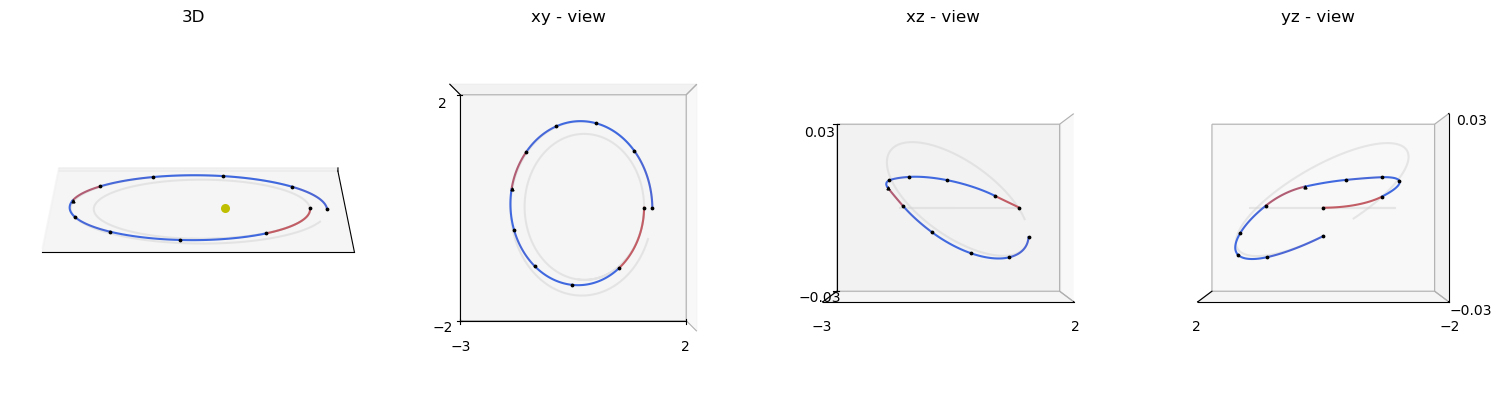

In [42]:
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")

axes = [ax3d, ax_xy, ax_xz, ax_yz]

for ax in axes:
    udp.plot(
        x=pop.champion_x,
        N=100,
        mark_segments=True,
        s=3,
        c="k",
        ax=ax,
        to_cartesian=lambda x: np.asarray(
            [x[0] * L, x[1] * L, x[2] * L, x[3] * V, x[4] * V, x[5] * V]
        ),
        orbit_color="lightgray",
    )

# Keep only boundary ticks to emphasize geometry
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])

ax3d.view_init(elev=20, azim=270)
ax3d.set_aspect("equal")
pk.plot.add_sun(ax3d)

ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

# Two-body dynamics (Modified Equinoctial Elements)

The same UDP workflow applies with a different state representation and integrator pair. Here we switch from Cartesian to MEE while keeping the optimization structure unchanged.

For state conventions and conversion utilities, see [Elements and conversions](../elements.rst).

In [45]:
# Load a MEE instance from the TOPS database
db = "Two-body MEE"
prob_name = "P0"
gym_problem = pk.trajopt.gym.tops_mee[prob_name]
print("Problem name: ", db + " " + prob_name)
print("Problem info: ", gym_problem["info"])

Problem name:  Two-body MEE P0
Problem info:  Dionysus problem (doi: 10.2514/1.G000379) - Fixed time


In [46]:
# ZOH integrators for two-body MEE dynamics
tol = 1e-16
tol_var = 1e-8

ta_twobody_mee = pk.ta.get_zoh_eq(tol)
ta_twobody_mee_var = pk.ta.get_zoh_eq_var(tol_var)

In [47]:
# Non-dimensional scales
MU = gym_problem["mu"]
L = gym_problem["state_s"][0]
MASS = gym_problem["m_s"]
TIME = np.sqrt(L**3 / MU)
V = L / TIME
ACC = V / TIME
F = MASS * ACC

# In MEE, only the semi-major-axis-like component is length-scaled
states = [it / L for it in gym_problem["state_s"][:1]] + [it for it in gym_problem["state_s"][1:6]]
statef = [it / L for it in gym_problem["state_f"][:1]] + [it for it in gym_problem["state_f"][1:6]]
ms = gym_problem["m_s"] / MASS
max_thrust = gym_problem["max_thrust"] / F
tof_bounds = [it / TIME for it in gym_problem["tof_bounds"]]

veff_nd = gym_problem["veff"] / V
ta_twobody_mee.pars[4] = 1.0 / veff_nd
ta_twobody_mee_var.pars[4] = 1.0 / veff_nd

In [48]:
# UDP configuration
nseg = 11
time_encoding = "uniform"
cut = 0.5

udp = pk.trajopt.zoh_point2point(
    states=states,
    statef=statef,
    ms=ms,
    max_thrust=max_thrust,
    tof_bounds=tof_bounds,
    mf_bounds=[ms / 10.0, ms],
    nseg=nseg,
    cut=cut,
    tas=[ta_twobody_mee, ta_twobody_mee_var],
    time_encoding=time_encoding,
    inequalities_for_tc=True,
    max_steps=1000,
 )
prob = pg.problem(udp)
prob.c_tol = 1e-6

In [67]:
pop = pg.population(prob, 1)
(pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).max(), (pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).min()

(2.0611357014720111e-06, -1.4823118779705252e-06)

In [68]:
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Final mass:", pop.champion_x[0] * MASS)
print("Final tof:", pop.champion_x[4*nseg+1] * TIME)

True
Final mass: 0.615843476965
Final tof: 60.7909197787


Text(0.5, 0.92, 'yz - view')

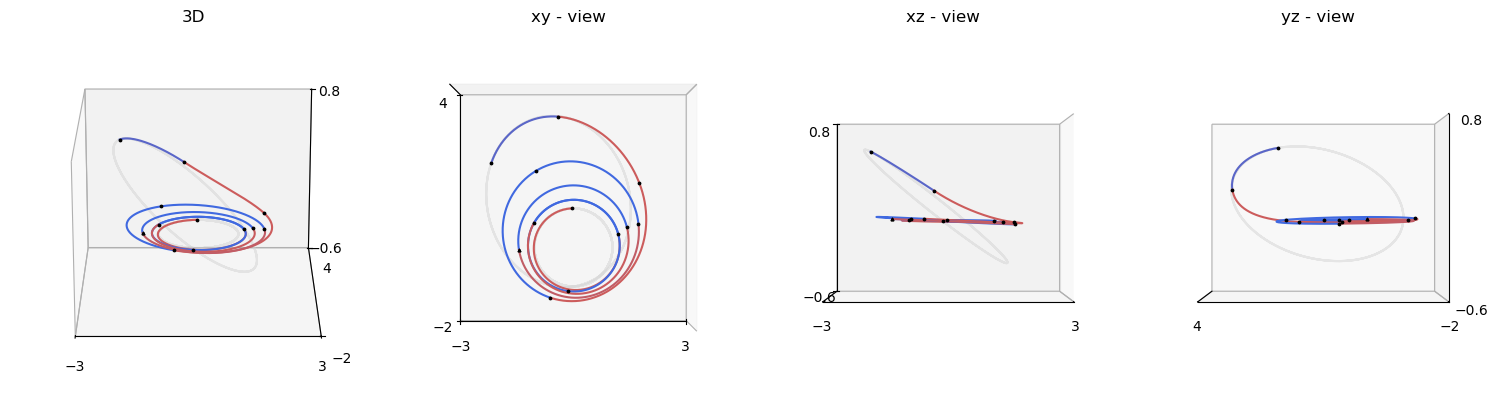

In [69]:
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")  # 3D view
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")  # look along +z (XY plane)
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")  # look along +y (XZ plane)
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")  # look along +x (YZ plane)

axes = [ax3d, ax_xy, ax_xz, ax_yz]

for ax in axes:
    udp.plot(
        x=pop.champion_x,
        N=300,
        mark_segments=True,
        s=3,
        c="k",
        ax=ax,
        to_cartesian=lambda x: np.array(
            pk.mee2ic([x[0] * L, x[1], x[2], x[3], x[4], x[5]], mu=1.0)
        ).flatten(),
        orbit_color="lightgray",
    )

# We remove the ticks for clarity
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])

# Main 3D view
ax3d.view_init(elev=20, azim=270)

# Plane-aligned views
ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

# Circular Restricted Three-Body Problem (CR3BP)

This section applies the same UDP workflow in CR3BP coordinates, with the corresponding ZOH CR3BP integrators and parameters.

For model-specific background, see [CR3BP dynamics](../propagation.rst).

In [74]:
# Load a CR3BP instance from the TOPS database
db = "Circular Restricted Three-Body Problem"
prob_name = "P0"
gym_problem = pk.trajopt.gym.tops_cr3bp[prob_name]
print("Problem name: ", db + " " + prob_name)
print("Problem info: ", gym_problem["info"])

Problem name:  Circular Restricted Three-Body Problem P0
Problem info:  Halo 2 Halo in fixed tof


In [75]:
# ZOH integrators for CR3BP dynamics
tol = 1e-16
tol_var = 1e-8

ta_cr3bp = pk.ta.get_zoh_cr3bp(tol)
ta_cr3bp_var = pk.ta.get_zoh_cr3bp_var(tol_var)

# CR3BP-specific parameters
veff_nd = gym_problem["veff"]
mu_cr3bp = gym_problem["mu_cr3bp"]
ta_cr3bp.pars[4] = 1.0 / veff_nd
ta_cr3bp_var.pars[4] = 1.0 / veff_nd
ta_cr3bp.pars[5] = mu_cr3bp
ta_cr3bp_var.pars[5] = mu_cr3bp

In [76]:
# UDP configuration
nseg = 10
time_encoding = "uniform"
cut = 0.5

udp = pk.trajopt.zoh_point2point(
    states=gym_problem["state_s"],
    statef=gym_problem["state_f"],
    ms=gym_problem["m_s"],
    max_thrust=gym_problem["max_thrust"],
    tof_bounds=gym_problem["tof_bounds"],
    mf_bounds=[gym_problem["m_s"] / 2.0, gym_problem["m_s"]],
    nseg=nseg,
    cut=cut,
    tas=[ta_cr3bp, ta_cr3bp_var],
    time_encoding=time_encoding,
    max_steps=1000,
    inequalities_for_tc=False,
 )
prob = pg.problem(udp)
prob.c_tol = 1e-6

In [81]:
pop = pg.population(prob, 1)
(pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).max(), (pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).min()

(1.4561294462006602e-06, -2.7896538594696096e-06)

In [82]:
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))
print("Final mass:", pop.champion_x[0] * MASS)
print("Final tof:", pop.champion_x[4*nseg+1] * TIME)

True
Final mass: 0.983160282028
Final tof: 4.99770747418


Text(0.5, 0.92, 'yz - view')

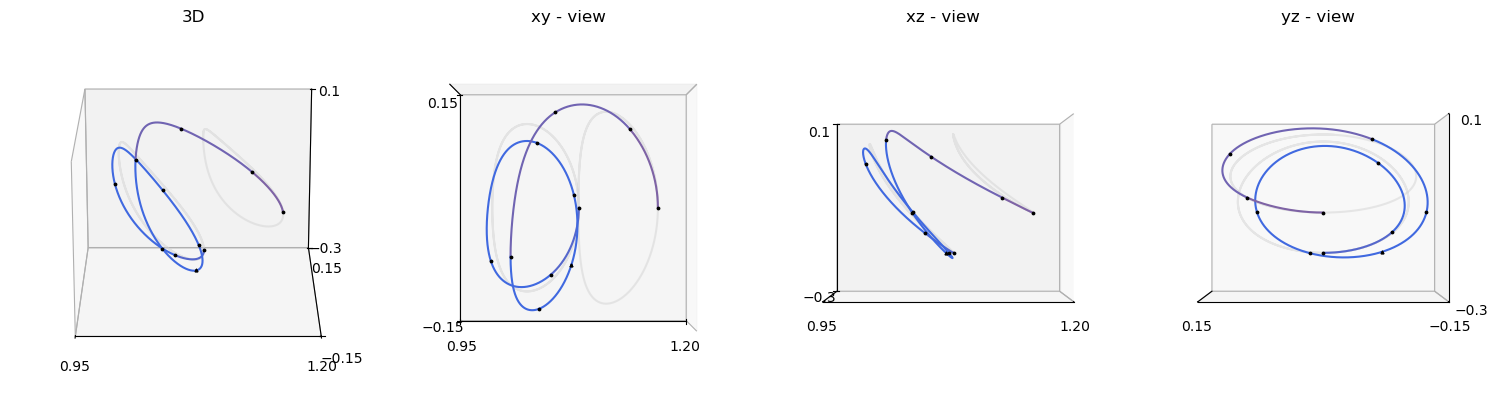

In [83]:
fig = plt.figure(figsize=(15, 4), layout="constrained")

ax3d = fig.add_subplot(1, 4, 1, projection="3d")  # 3D view
ax_xy = fig.add_subplot(1, 4, 2, projection="3d")  # look along +z (XY plane)
ax_xz = fig.add_subplot(1, 4, 3, projection="3d")  # look along +y (XZ plane)
ax_yz = fig.add_subplot(1, 4, 4, projection="3d")  # look along +x (YZ plane)

axes = [ax3d, ax_xy, ax_xz, ax_yz]
#xmin, xmax = 0.8, 1.3
#ymin, ymax = -0.3, 0.3
#zmin, zmax = -0.2, 0.2

for ax in axes:
    udp.plot(
        x=pop.champion_x,
        N=1000,
        mark_segments=True,
        s=3,
        c="k",
        ax=ax,
        orbit_color="lightgray",
    )

# We remove the ticks for clarity
for ax in axes:
    ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
    ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
    ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])
ax_xy.set_zticks([])
ax_xz.set_yticks([])
ax_yz.set_xticks([])


ax3d.view_init(elev=20, azim=270)

ax_xy.view_init(elev=90, azim=-90)
ax_xz.view_init(elev=0, azim=-90)
ax_yz.view_init(elev=0, azim=180)

ax3d.set_title("3D")
ax_xy.set_title("xy - view")
ax_xz.set_title("xz - view")
ax_yz.set_title("yz - view")

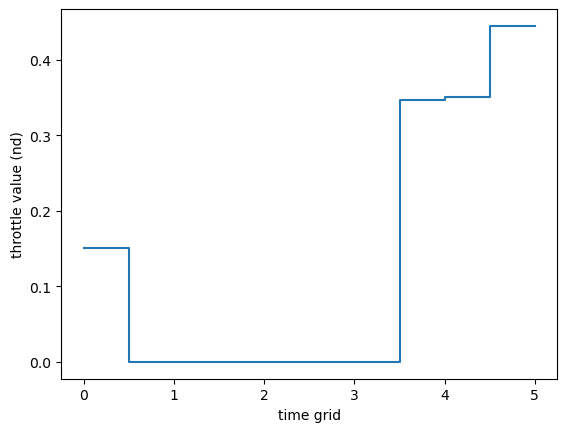

In [85]:
udp.plot_throttle(pop.champion_x);


# Solar-sail dynamics

For solar sailing, use the dedicated UDP {class}`pykep.trajopt.zoh_ss_point2point`.
The workflow is identical: scale units, instantiate integrators, build the UDP, verify gradients, and optimize.

For sail-leg details, use the generic [Zero-Order Hold leg tutorial](./leg_zoh.ipynb) with 6D dynamics and 2 controls, plus the [Trajectory optimization API](../trajopt.rst).

In [87]:
# Load a SOLARSAILING instance from the TOPS database
db = "ss"
prob_name = "P1"
gym_problem = pk.trajopt.gym.tops_ss[prob_name]
print("Problem name: ", db + " " + prob_name)
print("Problem info: ", gym_problem["info"])

Problem name:  ss P1
Problem info:  Eccentric (e=0.5, a=2) to highly-eccentric (e=0.9, a=10) orbit at periapsis (rp=1, nd)


In [88]:
# ZOH integrators for solar-sail dynamics
tol = 1e-16
tol_var = 1e-8

ta_ss = pk.ta.get_zoh_ss(tol)
ta_ss_var = pk.ta.get_zoh_ss_var(tol_var)

In [89]:
# Non-dimensional scales
MU = gym_problem["mu"]
L = gym_problem["L"]
TIME = np.sqrt(L**3 / MU)
V = L / TIME
ACC = V / TIME

# Scale states and bounds
states = [it / L for it in gym_problem["state_s"][:3]] + [it / V for it in gym_problem["state_s"][3:6]]
statef = [it / L for it in gym_problem["state_f"][:3]] + [it / V for it in gym_problem["state_f"][3:6]]
c_sail = gym_problem["c_sail"] / ACC
tof_bounds = [it / TIME for it in gym_problem["tof_bounds"]]

# Set sail acceleration parameter
ta_ss.pars[2] = c_sail
ta_ss_var.pars[2] = c_sail

In [90]:
# UDP configuration
nseg = 9
time_encoding = "uniform"
cut = 0.5

udp = pk.trajopt.zoh_ss_point2point(
    states=states,
    statef=statef,
    tof_bounds=tof_bounds,
    nseg=nseg,
    cut=cut,
    tas=[ta_ss, ta_ss_var],
    time_encoding=time_encoding,
    max_steps=1000,
 )
prob = pg.problem(udp)
prob.c_tol = 1e-6

In [92]:
pop = pg.population(prob, 1)
(pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).max(), (pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8)-udp.gradient(pop.champion_x)).min()

(3.323305667490839e-06, -4.2279427692193394e-06)

In [93]:
pop = algo.evolve(pop)
print(prob.feasibility_f(pop.champion_f))

True


Text(0.5, 0.92, '3D')

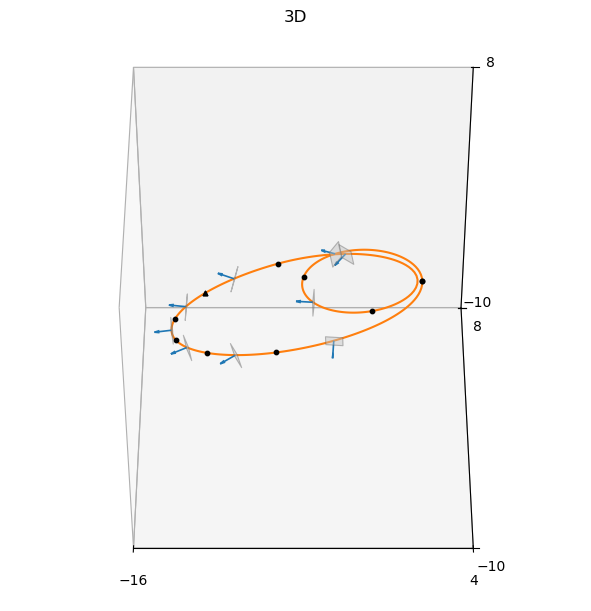

In [94]:
fig = plt.figure(figsize=(6, 6), layout="constrained")

ax = fig.add_subplot(1, 1, 1, projection="3d")  # 3D view

udp.plot(x=pop.champion_x, N=100, mark_segments=True, ax=ax, sail_size=0.5, s=10, c='k')


ax.set_xticks([ax.get_xticks()[0], ax.get_xticks()[-1]])
ax.set_yticks([ax.get_yticks()[0], ax.get_yticks()[-1]])
ax.set_zticks([ax.get_zticks()[0], ax.get_zticks()[-1]])


# Main 3D view
ax.view_init(elev=45, azim=270)


ax.set_title("3D")
